In [54]:
import snapatac2 as snap
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

In [2]:
from utils.utils import *

In [3]:
norm_frag = Path('./fragment_normal').glob('*.gz')
sample_name = str_extract([i.stem for i in norm_frag],'[\w-]+')
norm_frag = Path('./fragment_normal').glob('*.gz')
sample_path = [str(i) for i in norm_frag]
norm_frag_dict = dict(zip(sample_name,sample_path))

samples = ['260119T','260129T']
fragment_name = [f'fragment/{sample}_fragments.tsv.gz' for sample in samples]
pannet_frag_dict = dict(zip(samples,fragment_name))
frag_dict = norm_frag_dict|pannet_frag_dict

In [4]:
norm_obs = pd.read_csv('fragment_normal/obs.csv')
norm_obs['bc'] =norm_obs['donor'] + ':' + norm_obs['index']
pannet_obs = pd.read_csv('table/scATAC_PanNET_obs.csv')
normal_ct_dict = dict(zip(norm_obs['bc'],norm_obs['cell_type']))
panet_ct_dict = dict(zip(pannet_obs['Unnamed: 0'],pannet_obs['cell_type']))
ct_dict  = normal_ct_dict | panet_ct_dict

In [5]:
adata_temp = snap.pp.import_fragments(
    [i for i in frag_dict.values()],
    file= [f'scATAC_intergrate/{i}_raw.h5ad' for i in frag_dict.keys()],
    chrom_sizes=snap.genome.hg38,
    min_num_fragments=1000,
    n_jobs = 40,
    is_paired=True,
    sorted_by_barcode = False
)
snap.pp.add_tile_matrix(adata_temp, bin_size=5000)

  0%|          | 0/16 [00:00<?, ?it/s]/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of t

In [6]:
for adata in adata_temp:
    adata.close()

In [5]:
norm_adata = Path('./scATAC_intergrate').glob('*.h5ad')
sample_name = str_extract([i.stem for i in norm_adata],'[\w-]+')
norm_adata = Path('./scATAC_intergrate').glob('*.h5ad')
sample_path = [str(i) for i in tqdm(norm_adata)]
adata_dict = dict(zip(sample_name,sample_path))

16it [00:00, 17739.59it/s]


In [6]:
adataset = snap.AnnDataSet(
    adatas=[(key,v) for key,v in adata_dict.items()],
    filename="scATAC_intergrat_adata.h5ads"
)

In [7]:
adataset.obs['sample_name'] = str_extract(list(adataset.obs['sample']),'[A-Za-z0-9-]+')
unique_cell_ids = [sa + ':' + bc for sa, bc in zip(adataset.obs['sample_name'], adataset.obs_names)]
adataset.obs_names = unique_cell_ids

In [8]:
adataset.obsm['fragment_paired'] = adataset.adatas.obsm['fragment_paired']

In [9]:
adata = adataset.to_adata()

In [10]:
adata.obs['cell_type'] = adata.obs.index.map(ct_dict)
adata_sub = adata[adata.obs["cell_type"].notna()].copy()

# Total cell type

In [11]:
adata_sub = run_lsi(
    adata_sub,
    n_components=30,
    n_features=100000,
    use_snap_feature=True,
    binarize=False
)

2026-05-21 17:11:18 - INFO - Selected 100000 features.


In [12]:
adata_sub.obs.head()

,sample,sample_name,cell_type
SAMP-1136:AAACGAAAGAGTCCGA-2,SAMP-1136_raw,SAMP-1136,Beta
SAMP-1136:AAACGAAAGGTGATGC-2,SAMP-1136_raw,SAMP-1136,Alpha
SAMP-1136:AAACGAAAGGTTAACA-2,SAMP-1136_raw,SAMP-1136,Beta
SAMP-1136:AAACGAACAACGGACA-2,SAMP-1136_raw,SAMP-1136,Alpha
SAMP-1136:AAACGAACAAGTCCTA-2,SAMP-1136_raw,SAMP-1136,Beta


In [13]:
snap.pp.harmony(adata_sub, use_rep = 'X_lsi',batch="sample_name", max_iter_harmony=20)
snap.tl.umap(adata_sub, use_rep="X_lsi_harmony",n_neighbors=30,min_dist=0.1)

2026-05-21 17:16:35,779 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-21 17:16:35 - INFO - Computing initial centroids with sklearn.KMeans...


2026-05-21 17:16:42,943 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-05-21 17:16:42 - INFO - sklearn.KMeans initialization complete.
2026-05-21 17:16:43,695 - harmonypy - INFO - Iteration 1 of 20
2026-05-21 17:16:43 - INFO - Iteration 1 of 20
2026-05-21 17:17:36,976 - harmonypy - INFO - Iteration 2 of 20
2026-05-21 17:17:36 - INFO - Iteration 2 of 20
2026-05-21 17:18:28,811 - harmonypy - INFO - Iteration 3 of 20
2026-05-21 17:18:28 - INFO - Iteration 3 of 20
2026-05-21 17:19:20,426 - harmonypy - INFO - Iteration 4 of 20
2026-05-21 17:19:20 - INFO - Iteration 4 of 20
2026-05-21 17:20:10,826 - harmonypy - INFO - Iteration 5 of 20
2026-05-21 17:20:10 - INFO - Iteration 5 of 20
2026-05-21 17:21:01,728 - harmonypy - INFO - Iteration 6 of 20
2026-05-21 17:21:01 - INFO - Iteration 6 of 20
2026-05-21 17:21:46,574 - harmonypy - INFO - Iteration 7 of 20
2026-05-21 17:21:46 - INFO - Iteration 7 of 20
2026-05-21 17:22:26,760 - harmonypy - INFO - Iteration 8 of 20
2026-05-21 17

In [17]:
!pip install matplotlib_inline==0.1.7

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/8f/8e/9ad090d3553c280a8060fbf6e24dc1c0c29704ee7d1c372f0c174aa59285/matplotlib_inline-0.1.7-py3-none-any.whl (9.9 kB)
  Attempting uninstall: matplotlib_inline
    Found existing installation: matplotlib-inline 0.2.1
    Uninstalling matplotlib-inline-0.2.1:
      Successfully uninstalled matplotlib-inline-0.2.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
omicverse 1.7.7 requires ctxcore>=0.2, which is not installed.
omicverse 1.7.7 requires datetime>=4.5, which is not installed.
omicverse 1.7.7 requires graphtools>=1.5, which is not installed.
omicverse 1.7.7 requires ktplotspy>=0.1, which is not installed.
omicverse 1.7.7 requires metatime>=1.3.0, which is not installed.
omicverse 1.7.7 requires mofax>=0.3, which is not installed.
omicvers

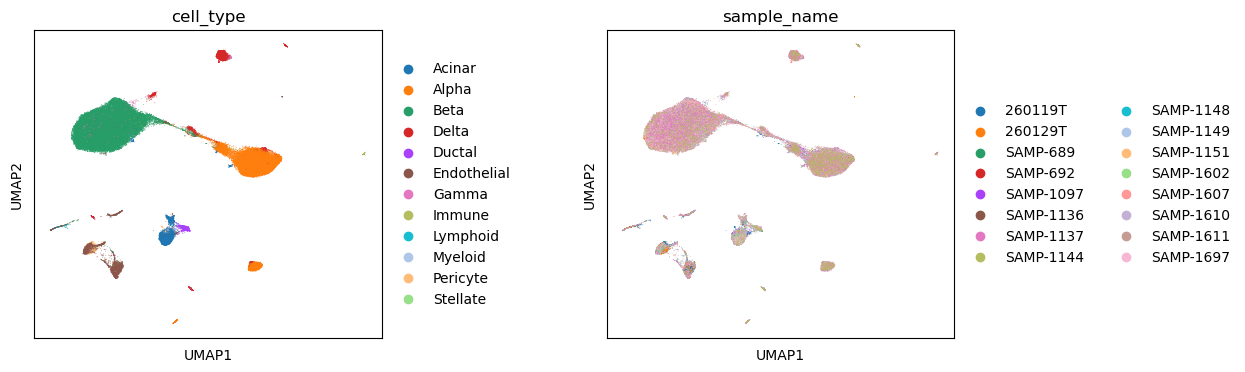

In [18]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(adata_sub,color = ['cell_type','sample_name'],wspace=0.5)

In [20]:
adata_sub.write_h5ad('integrate_h5ad/scATAC_intergrat_adata.h5ad',compression='gzip')

In [21]:
adataset.close()

# Subset beta cell type

In [22]:
import numpy as np

In [9]:
adata_sub = sc.read_h5ad('integrate_h5ad/scATAC_intergrat_adata.h5ad')

In [23]:
beta = adata_sub[adata_sub.obs['cell_type'] == 'Beta'].copy()

In [29]:
beta.obs["tissue"] = np.where(
    beta.obs["sample_name"].astype(str).str.startswith("SAMP"),
    "Normal",
    "PanNET"
)

... storing 'tissue' as categorical


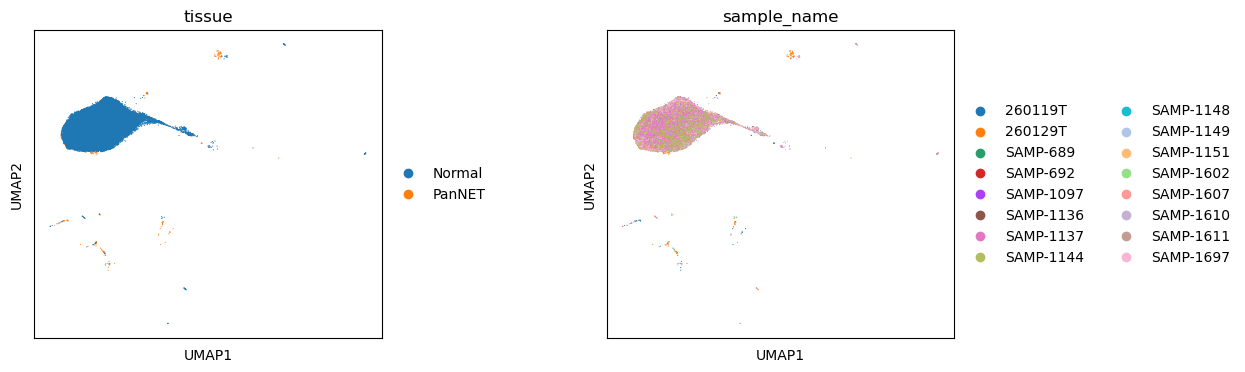

In [30]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(beta,color = ['tissue','sample_name'],wspace=0.5)

In [31]:
snap.tl.macs3(beta, groupby='tissue')

2026-05-21 18:10:13 - INFO - Exporting fragments...
2026-05-21 18:12:51 - INFO - Calling peaks...
  0%|          | 0/2 [00:00<?, ?it/s]/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
100%|██████████| 2/2 [34:36<00:00, 1038.48s/it]


In [32]:
beta_merged_peaks = snap.tl.merge_peaks(beta.uns['macs3'], chrom_sizes=snap.genome.hg38)
beta_merged_peaks_df = beta_merged_peaks.to_pandas()
beta_merged_peaks_df.to_csv('table/scATAC_beta_peak_intergtated.csv')

In [33]:
peak_mat_beta = snap.pp.make_peak_matrix(beta, use_rep=beta_merged_peaks['Peaks'])

# beta peak

In [35]:
sample_counts = peak_mat_beta.obs["sample_name"].value_counts()

keep_samples = sample_counts[sample_counts > 2000].index

peak_mat_beta = peak_mat_beta[
    peak_mat_beta.obs["sample_name"].isin(keep_samples)
].copy()

In [41]:
peak_mat_beta = run_lsi(
    peak_mat_beta,
    n_components=30,
    n_features=50000,
    use_snap_feature=True,
    binarize=False
)

2026-05-21 19:43:51 - INFO - Selected 50000 features.


In [ ]:
snap.pp.harmony(peak_mat_beta, use_rep = 'X_lsi',batch="sample_name", max_iter_harmony=20)


2026-05-21 19:44:56,293 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-21 19:44:56 - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-21 19:45:03,227 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-05-21 19:45:03 - INFO - sklearn.KMeans initialization complete.
2026-05-21 19:45:03,527 - harmonypy - INFO - Iteration 1 of 20
2026-05-21 19:45:03 - INFO - Iteration 1 of 20
2026-05-21 19:45:26,749 - harmonypy - INFO - Iteration 2 of 20
2026-05-21 19:45:26 - INFO - Iteration 2 of 20
2026-05-21 19:45:55,096 - harmonypy - INFO - Converged after 2 iterations
2026-05-21 19:45:55 - INFO - Converged after 2 iterations
/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [44]:
snap.tl.umap(peak_mat_beta, use_rep="X_lsi_harmony",n_neighbors=30,min_dist=1)

/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


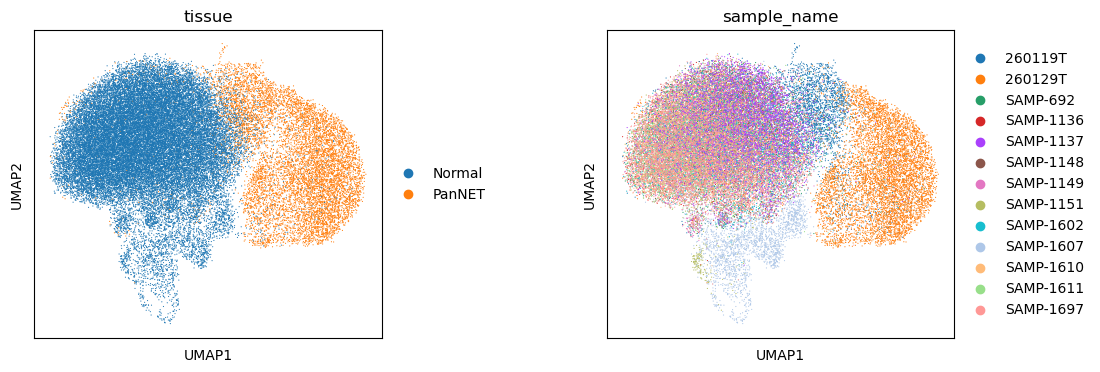

In [51]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(peak_mat_beta,color = ['tissue','sample_name'],wspace=0.5,save = 'figure3A.pdf')

In [52]:
peak_mat_beta.write_h5ad('integrate_h5ad/scATAC_beta_peak_intergtated_final_annoated.h5ad',compression='gzip')

In [49]:
peak_mat_beta.obs.to_csv('table/scATAC_beta_peak_intergtated_final_annoated_obs.csv')

In [55]:
peak_mat_beta

AnnData object with n_obs × n_vars = 45047 × 231199
    obs: 'sample', 'sample_name', 'cell_type', 'tissue'
    var: 'count', 'selected'
    uns: 'tissue_colors', 'sample_name_colors'
    obsm: 'X_lsi', 'X_lsi_harmony', 'X_umap'

In [58]:
snap.ex.export_coverage(beta, groupby='tissue',output_format  = 'bigwig', suffix='.bigwig')

2026-05-22 13:27:01 - INFO - Exporting fragments...


2026-05-22 13:31:15 - INFO - Computing coverage...


{'PanNET': PosixPath('PanNET.bigwig'), 'Normal': PosixPath('Normal.bigwig')}